In [7]:
# Step 1: Install and Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from wordcloud import WordCloud

# Download necessary NLTK data files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
# Step 2: Load a Realistic Customer Reviews Dataset
# Using a sample dataset of customer reviews for demonstration in Google Colab
data = {
    'review_text': [
        "Absolutely love this product! It exceeded all my expectations and works wonderfully.",
        "Terrible quality. It broke down after just two days of use. Complete waste of money.",
        "The item is okay, nothing special. It does the job, but the shipping took way too long.",
        "Fantastic customer service and a brilliant product! Highly recommend to everyone.",
        "Awful experience. The device arrived damaged and the support team never replied.",
        "It's an average product for a decent price. Neither amazing nor bad.",
        "Best purchase I've made this year! Super easy to use and very durable.",
        "Worst product ever. Stopped working immediately and smells like burnt plastic."
    ]
}

df = pd.DataFrame(data)
df.head()

,review_text
0,Absolutely love this product! It exceeded all ...
1,Terrible quality. It broke down after just two...
2,"The item is okay, nothing special. It does the..."
3,Fantastic customer service and a brilliant pro...
4,Awful experience. The device arrived damaged a...


In [9]:
# Step 3: Text Preprocessing Function
import nltk.data
nltk.data.path.append('/root/nltk_data')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Tokenize words
    tokens = word_tokenize(text)
    # Remove punctuation and stopwords, then lemmatize
    cleaned_tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token.isalnum() and token not in stop_words
    ]
    return " ".join(cleaned_tokens)

# Apply preprocessing
df['cleaned_text'] = df['review_text'].apply(preprocess_text)
df[['review_text', 'cleaned_text']]

,review_text,cleaned_text
0,Absolutely love this product! It exceeded all ...,absolutely love product exceeded expectation w...
1,Terrible quality. It broke down after just two...,terrible quality broke two day use complete wa...
2,"The item is okay, nothing special. It does the...",item okay nothing special job shipping took wa...
3,Fantastic customer service and a brilliant pro...,fantastic customer service brilliant product h...
4,Awful experience. The device arrived damaged a...,awful experience device arrived damaged suppor...
5,It's an average product for a decent price. Ne...,average product decent price neither amazing bad
6,Best purchase I've made this year! Super easy ...,best purchase made year super easy use durable
7,Worst product ever. Stopped working immediatel...,worst product ever stopped working immediately...


In [10]:
# Step 4: Sentiment Analysis using TextBlob
def get_sentiment(text):
    analysis = TextBlob(text)
    # Polarity ranges from -1.0 (very negative) to 1.0 (very positive)
    if analysis.sentiment.polarity > 0.1:
        return 'Positive'
    elif analysis.sentiment.polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df['polarity'] = df['review_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['sentiment'] = df['review_text'].apply(get_sentiment)

df[['review_text', 'polarity', 'sentiment']]

,review_text,polarity,sentiment
0,Absolutely love this product! It exceeded all ...,0.812500,Positive
1,Terrible quality. It broke down after just two...,-0.313889,Negative
2,"The item is okay, nothing special. It does the...",0.269048,Positive
3,Fantastic customer service and a brilliant pro...,0.520000,Positive
4,Awful experience. The device arrived damaged a...,-1.000000,Negative
5,It's an average product for a decent price. Ne...,-0.020833,Neutral
6,Best purchase I've made this year! Super easy ...,0.491667,Positive
7,Worst product ever. Stopped working immediatel...,-1.000000,Negative


/tmp/ipykernel_3005/1376701446.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='Set2')


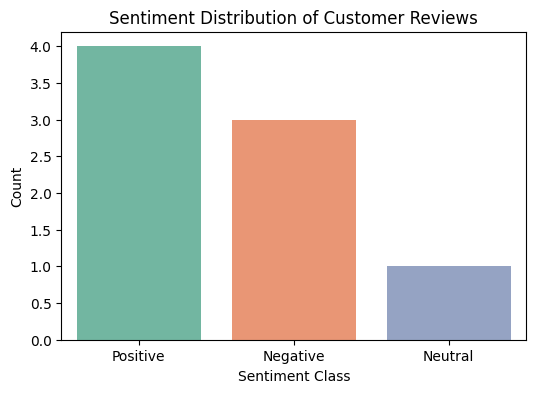

In [11]:
# Step 5: Visualize Sentiment Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df, palette='Set2')
plt.title('Sentiment Distribution of Customer Reviews')
plt.xlabel('Sentiment Class')
plt.ylabel('Count')
plt.show()

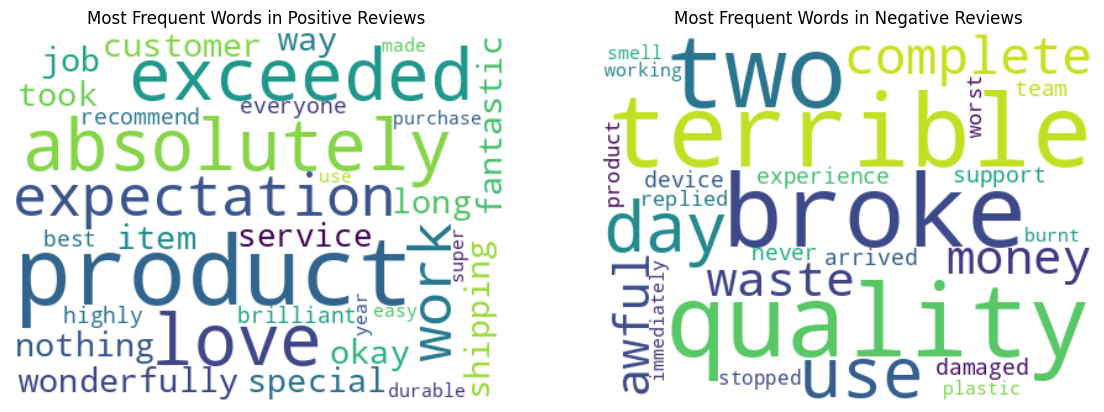

In [12]:
# Step 6: Generate Word Clouds for Positive and Negative Reviews
positive_text = " ".join(df[df['sentiment'] == 'Positive']['cleaned_text'])
negative_text = " ".join(df[df['sentiment'] == 'Negative']['cleaned_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positive Word Cloud
wordcloud_pos = WordCloud(width=400, height=300, background_color='white').generate(positive_text)
axes[0].imshow(wordcloud_pos, interpolation='bilinear')
axes[0].set_title('Most Frequent Words in Positive Reviews')
axes[0].axis('off')

# Negative Word Cloud
wordcloud_neg = WordCloud(width=400, height=300, background_color='white').generate(negative_text)
axes[1].imshow(wordcloud_neg, interpolation='bilinear')
axes[1].set_title('Most Frequent Words in Negative Reviews')
axes[1].axis('off')

plt.show()

## Project Showcase: Customer Review Sentiment Analysis

Thrilled to share a project from my Data Analysis Internship with @Codveda!

**Project Goal**: To analyze customer reviews to understand sentiment (positive, negative, neutral) and identify key themes.

**Key Steps & Insights**:

1.  **Data Loading & Preprocessing**: Loaded a sample dataset of customer reviews. Preprocessed the text by converting to lowercase, tokenizing, removing stopwords, and lemmatizing to prepare it for analysis.
2.  **Sentiment Analysis**: Utilized `TextBlob` to calculate polarity scores for each review and classify them into 'Positive', 'Negative', or 'Neutral' sentiments.
3.  **Sentiment Distribution Visualization**: Created a count plot to visualize the overall distribution of sentiments across the reviews, providing a clear overview of customer satisfaction.
4.  **Word Cloud Generation**: Generated word clouds for both positive and negative reviews to visually highlight the most frequently used words in each category. This helped in quickly identifying key attributes contributing to positive and negative experiences.

**Tools Used**: Python, Pandas, NLTK (for text preprocessing), TextBlob (for sentiment analysis), Matplotlib, Seaborn, and WordCloud (for visualizations).

This project provided valuable experience in natural language processing (NLP) and sentiment analysis, essential skills for understanding customer feedback and improving product/service offerings.

#DataAnalysis #SentimentAnalysis #NLP #CustomerReviews #Python #Internship #Codveda #DataScience